In [18]:
!pip install astroquery
!pip install lmfit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.7/97.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.0 MB/s eta 0:00:00


In [13]:
from astroquery.sdss import SDSS
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.io import fits
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.visualization import make_lupton_rgb
import pandas as pd

In [ ]:
https://ps1images.stsci.edu/cgi-bin/ps1cutouts?pos=136.64++%2B0.25722&filter=color&filter=g&filter=r&filter=i&filter=z&filter=y&filetypes=stack&auxiliary=data&size=240&output_size=0&verbose=0&autoscale=99.500000&catlist=

#https://ps1images.stsci.edu/cgi-bin/ps1cutouts?pos=136.64++%2B0.25722&filter=color&filter=g&filter=r&filter=i&filter=z&filter=y&filetypes=stack&auxiliary=data&size=240&output_size=0&verbose=0&autoscale=99.500000&catlist=

In [35]:
#descargar una imagen del telescopio SDSS de una galaxia con coordenadas ra y dec, el tamaño de la imagen es de 30 arcsec
coord = SkyCoord(
    ra=201.649435*u.deg,
    dec=32.760895*u.deg,
    frame='icrs'
)

# Descargar imagen
images = SDSS.get_images(
    coordinates=coord,
    band='r'
)

hdu = images[0][0]

data = hdu.data
wcs = WCS(hdu.header)

# Recorte de 30 arcsec x 30 arcsec
cutout = Cutout2D(
    data,
    position=coord,
    size=(30*u.arcsec, 30*u.arcsec),
    wcs=wcs
)

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.


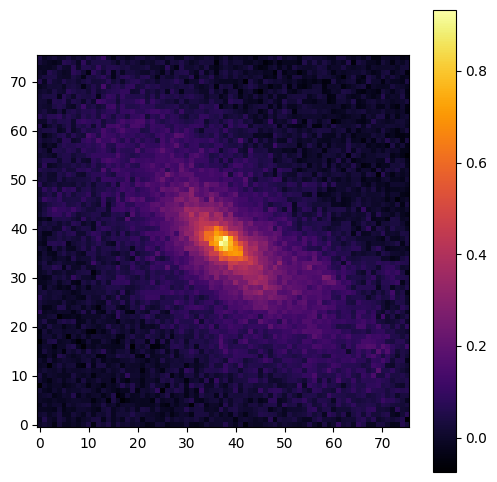

In [4]:
plt.figure(figsize=(6,6))
plt.imshow(cutout.data, origin='lower', cmap='inferno')
plt.colorbar()
plt.show()

In [5]:
#los datos astronómicos vienen en un formato fits que almacena los metadatos asi como los datos
#en este código estamos seleccionando únicamente los datos de la imagen
image = cutout.data

In [6]:
#Primero Calculo las estadísticas descriptivas
media = np.mean(image)
mediana = np.median(image)
desviacion_estandar = np.std(image)
valor_minimo = np.min(image)
valor_maximo = np.max(image)

# Mostrar los resultados
print(f"Media:              {media:.4f}")
print(f"Mediana:            {mediana:.4f}")
print(f"Desviación Estándar: {desviacion_estandar:.4f}")
print(f"Valor Mínimo:        {valor_minimo:.4f}")
print(f"Valor Máximo:        {valor_maximo:.4f}")

Media:              0.0634
Mediana:            0.0421
Desviación Estándar: 0.0924
Valor Mínimo:        -0.0748
Valor Máximo:        0.9326


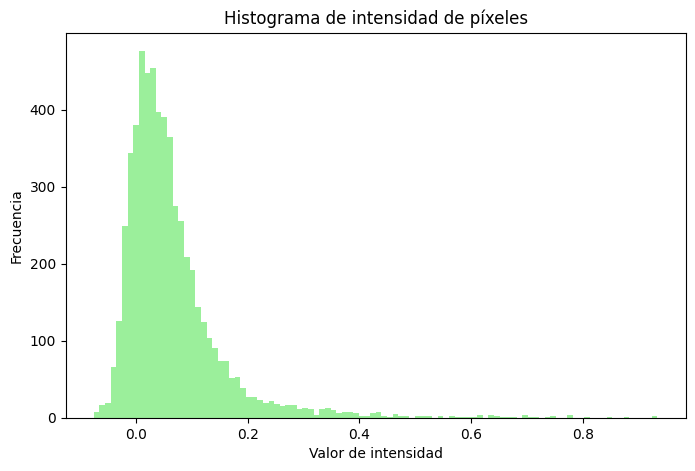

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(image.flatten(), bins=100, color='lightgreen', alpha=0.9)

plt.title('Histograma de intensidad de píxeles')
plt.xlabel('Valor de intensidad')
plt.ylabel('Frecuencia')

plt.grid(False)

plt.show()

In [10]:
# Aplicar la transformación de raíz cuadrada
image_sqrt = np.sqrt(image)

/tmp/ipykernel_736/471312432.py:2: RuntimeWarning: invalid value encountered in sqrt
  image_sqrt = np.sqrt(image)


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_736/2957639455.py:7: SyntaxWarning: invalid escape sequence '\s'
  fig.colorbar(im, ax=axes[0], label='Intensidad ($\sqrt{I}$)')
/tmp/ipykernel_736/2957639455.py:11: SyntaxWarning: invalid escape sequence '\s'
  axes[1].set_title('Histograma de intensidad de píxeles ($\sqrt{I}$)')


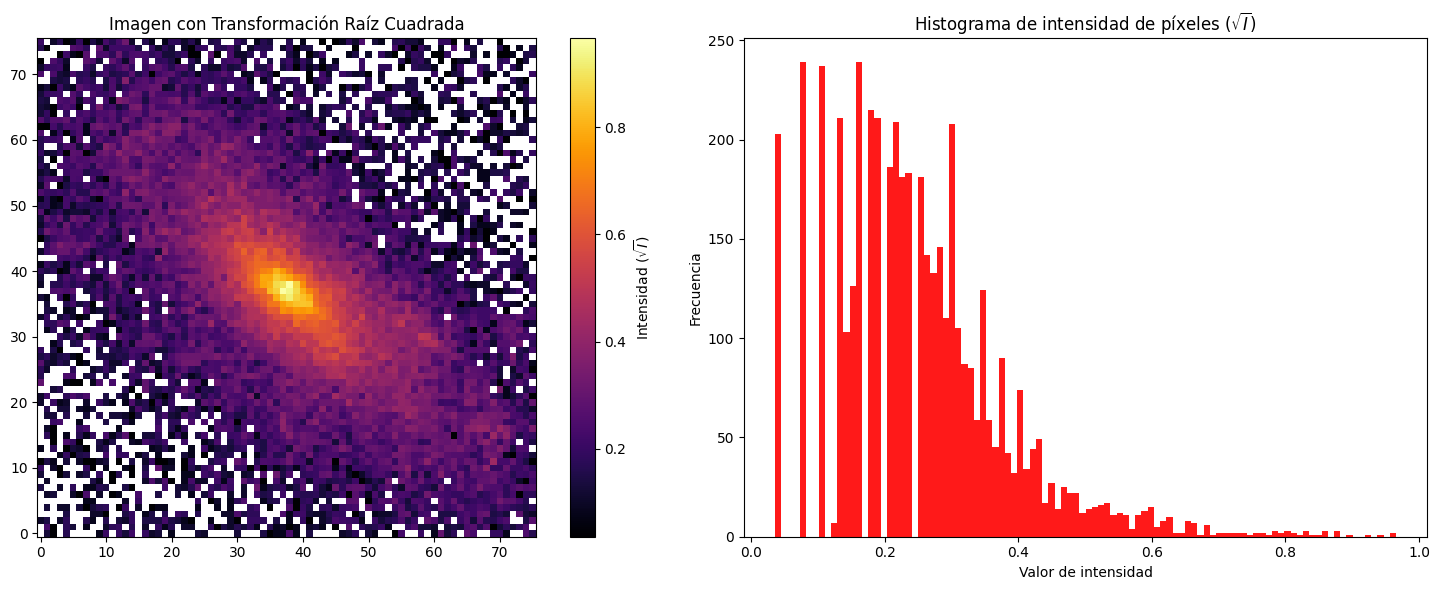

In [11]:
# Graficar la imagen transformada y su histograma lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de la imagen transformada
im = axes[0].imshow(image_sqrt, origin='lower', cmap='inferno')
axes[0].set_title('Imagen con Transformación Raíz Cuadrada')
fig.colorbar(im, ax=axes[0], label='Intensidad ($\sqrt{I}$)')

# Gráfico del histograma de los datos transformados
axes[1].hist(image_sqrt.ravel(), bins=100, color='red', alpha=0.9)
axes[1].set_title('Histograma de intensidad de píxeles ($\sqrt{I}$)')
axes[1].set_xlabel('Valor de intensidad')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(False)

plt.tight_layout()
plt.show()

In [23]:
from lmfit import Model

In [25]:
def gaussian(x, amp, cen, wid):
    """1-d gaussian: gaussian(x, amp, cen, wid)"""
    return (amp / (np.sqrt(2*np.pi) * wid)) * np.exp(-(x-cen)**2 / (2*wid**2))

In [26]:
gmodel = Model(gaussian)

In [27]:
data_co10=pd.read_csv("/content/drive/MyDrive/VALES/MOMENTS/600656_co10.txt", sep="\s+")
data_CO10= pd.DataFrame(data_co10,index=list(range(0, 70, 1)))

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_736/4122876503.py:1: SyntaxWarning: invalid escape sequence '\s'
  data_co10=pd.read_csv("/content/drive/MyDrive/VALES/MOMENTS/600656_co10.txt", sep="\s+")


In [28]:
max_guess_co10=np.max(data_CO10["flux"])

In [29]:
result_fitting_co10 = gmodel.fit(data_CO10["flux"], x=data_CO10["vel"], amp=max_guess_co10, cen=0.0, wid=300)

In [30]:
print(result_fitting_co10.fit_report())

[[Model]]
    Model(gaussian)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 143
    # data points      = 70
    # variables        = 3
    chi-square         = 2.8129e-05
    reduced chi-square = 4.1983e-07
    Akaike info crit   = -1024.90503
    Bayesian info crit = -1018.15954
    R-squared          = 0.54324950
[[Variables]]
    amp:  0.84196928 +/- 0.09921873 (11.78%) (init = 0.00356562)
    cen:  64.0147893 +/- 20.0017566 (31.25%) (init = 0)
    wid:  147.001384 +/- 20.0019566 (13.61%) (init = 300)
[[Correlations]] (unreported correlations are < 0.100)
    C(amp, wid) = +0.5774


(-2.0, 4.2)

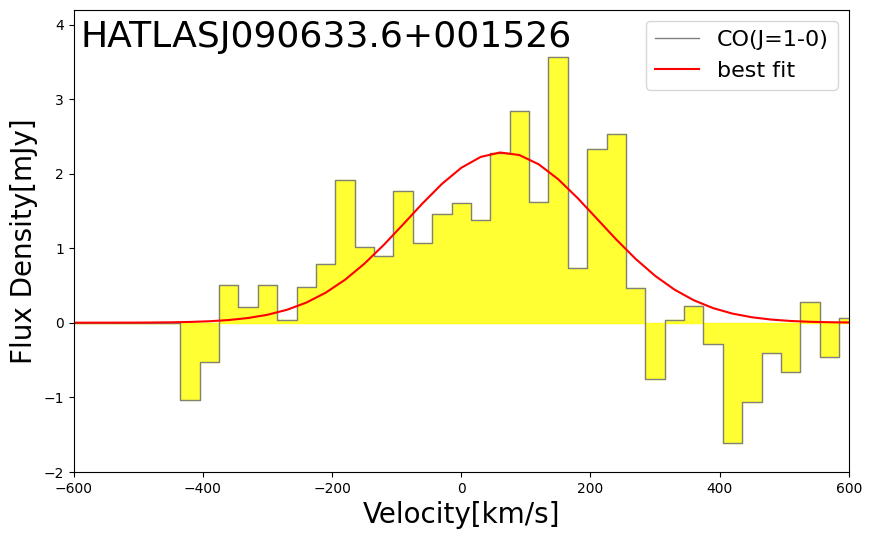

In [31]:
#PLOT THE SPECTRUM IN velocity
fig, ax1 = plt.subplots(figsize = (10,6))
ax1.step(data_CO10['vel'],data_CO10['flux']*1000,color = 'grey', linewidth= 1, where = 'mid',label='CO(J=1-0)')
plt.fill_between(data_CO10['vel'], data_CO10['flux']*1000,step="mid",color='yellow', alpha=0.8)
plt.plot(data_CO10["vel"], 1000*result_fitting_co10.best_fit, '-', label='best fit',color='red')
ax1.set_xlabel('Velocity[km/s]', size=20)  #Nombre del eje x
ax1.set_ylabel('Flux Density[mJy]', size=20)  #Nombre del eje y
ax1.annotate("HATLASJ090633.6+001526",(-590, 3.7),fontsize=26)#28
plt.legend(fontsize='16')#MOSTRAR EL LEGEND
ax1.set_xlim([-600, 600])
ax1.set_ylim([-2, 4.2])
#plt.grid()

In [36]:
data_co32=pd.read_csv("/content/drive/MyDrive/VALES/MOMENTS/600656_co32.txt", sep="\s+")
data_CO32= pd.DataFrame(data_co32,index=list(range(0, 70, 1)))

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_736/1634915780.py:1: SyntaxWarning: invalid escape sequence '\s'
  data_co32=pd.read_csv("/content/drive/MyDrive/VALES/MOMENTS/600656_co32.txt", sep="\s+")
